In [2]:
%load_ext autoreload
%autoreload 2
import os
import functools
from pathlib import Path
import numpy as np

import re
import matplotlib.pyplot as plt

imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())


os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False

dataset_location = "./data/clevr-real-block-v3"
dataset_location = Path(dataset_location)

model_location = Path("./data/models/")
model_path = model_location / "clevr-act-7-depth_text_aug" / "checkpoint-4687"

save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

if "depth_depth_l40" in str(model_path):
    return_depth = True

print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

dataset_location data/clevr-real-block-v3
moadel_path is data/models/clevr-act-7-depth_text_aug/checkpoint-4687


dataset len 160
160


  0%|          | 0/2 [00:00<?, ?it/s]


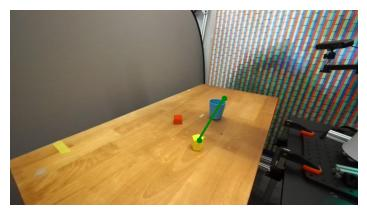
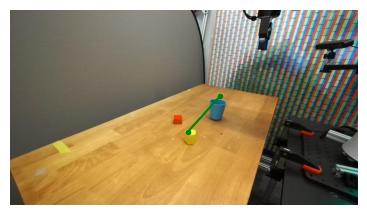

In [3]:
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter


test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example

def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
print(len(test_dataset))
num_samples = 2
html_imgs = ""
for i in tqdm(range(num_samples)):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"])
    
display(HTML(html_imgs))

In [4]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

DEVICE = 'cuda' # torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        padding="longest"
    ).to(TORCH_DTYPE).to(DEVICE)
    return inputs

Using device: cuda
loaded processor.


## Evaluate beams

In [ ]:
save_folder = "data/beam3_original/"
#save_folder = "data/beam_std_original/"
crop_size = 1300
episode_i = 0

with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
    sequences = np.load(f)
    scores = np.load(f)
    sequence_scores = np.load(f)

# prefix (text label and robot pos) + suffix (start pos and end pos)
decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
print(decoded_str)

# (n_beams, encoded_steps)
print(sequences.shape)

# (steps, n_beams, n_tokens)
print(scores.shape)

# n_beams
print(sequence_scores.shape)

In [ ]:
# load all episodes and beams
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)
test_samples = len(test_dataset)
sample_list = list(range(test_samples))

pred_list = []
score_list = [] # [i] = np.ndarray(n_beams, steps)
beam_list = [] # [i] = [beam1_str, beam2_str ...]
print_samples = 2
for episode_i in sample_list:
    if episode_i < print_samples:
        print("==== episode", episode_i)
    
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores = np.load(f)
        sequence_scores = np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
    
    pred_list.append(decoded_str)
    score_list.append(sequence_scores)

    beams = []
    for i in range(3):
        # prefix\nsuffix
        suffix = processor.decode(sequences[i], skip_special_tokens=True).split('\n')[1]
        beams.append(suffix)
        if episode_i < print_samples:
            print(suffix, sequence_scores[i])
        
    beam_list.append(beams)


In [ ]:
# evaluate all episodes and beams
import re

# Max Argus evaluation
results = []
beam_scores = []
beam_errors = []
best_beams = []
for i, pred in enumerate(pred_list):
    # ground truth
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)])
    decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)])
    
    if len(suffix_p) != 12 or len(decode_p) != 12:
        continue

    # maniskill coors -> image coors
    image = test_dataset[i][0]
    h, w = image.size
    suffix_p[[0, 6]] *= h/1024
    suffix_p[[1, 7]] *= w/1024
    decode_p[[0, 6]] *= h/1024
    decode_p[[1, 7]] *= w/1024

    # === find beam with minimum error (oracle)
    error = []
    for beam_i in range(3):
        decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)])
        decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][beam_i])])
        decode_p[[0, 6]] *= h/1024
        decode_p[[1, 7]] *= w/1024
        #print(decode_p)

        pred_diff = np.mean(np.abs(np.array(suffix_p) - np.array(decode_p)))
        error.append(pred_diff)
        beam_errors.append(pred_diff)
        beam_scores.append(score_list[i][beam_i])
    best = np.argmin(error)
    best_beams.append(best)
    decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][best])])
    decode_p[[0, 6]] *= h/1024
    decode_p[[1, 7]] *= w/1024

    
    # === the most likely beam. sequence_scores are sorted by decreasing order
    most_likely = True # CHANGE ME
    if most_likely:
        decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][0])])
        decode_p[[0, 6]] *= h/1024
        decode_p[[1, 7]] *= w/1024


    
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

#results[:, 0:2] = results[:, 0:2]/1024*224 
#results[:, 6:8] = results[:, 6:8]/1024*224 

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()

In [ ]:
import numpy as np
from scipy import stats

if save_folder == "data/beam3_original/":
    method_name = "Beam search-NMS"
elif save_folder == "data/beam_std_original/":
    method_name = "Beam search"
else:
    raise ValueError

beam_scores = np.array(beam_scores)
beam_errors = np.array(beam_errors)

res = stats.spearmanr(-beam_scores, beam_errors)
res.statistic
print(f"{method_name} Spearman Rank Coefficient: {res.statistic:0.02f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(-np.array(beam_scores[0::3]), beam_errors[0::3], marker='.', label="beam #1")
ax.scatter(-np.array(beam_scores[1::3]), beam_errors[1::3], marker='.', label="beam #2")
ax.scatter(-np.array(beam_scores[2::3]), beam_errors[2::3], marker='.', label="beam #3")
#ax.set_xlim(0, 1024)

    
ax.set_title(f"{method_name} on block-v3")
ax.set_ylabel("traj. mean L1 error")
ax.set_xlabel("beam negative log-probabilities")

coef = np.polyfit(beam_scores,beam_errors, 1)
poly1d_fn = np.poly1d(coef)

x_range = np.linspace(min(-beam_scores), max(-beam_scores), 10)
ax.plot(x_range, poly1d_fn(-x_range), '--k', label='linear fit')

ax.legend()
fig.tight_layout()

fn = f"{method_name.lower().replace(' ','_')}.pdf"
print("saving to: ", fn)
plt.savefig(fn)
plt.show()

In [ ]:
fig, ax = plt.subplots()

ax.bar([0, 1, 2], np.array([best_beams.count(0), best_beams.count(1), best_beams.count(2)])/len(best_beams)*100)
#ax.set_xlim(0, 1024)
ax.set_ylabel("frequency [%]")
ax.set_xlabel("# of beam")
ax.set_title("Index of best beam")

## Object detection style

In [120]:
save_folder = "data/beam3_original/"
#save_folder = "data/beam_std_original/"
#save_folder = "data/beam3_700/"
#save_folder = "data/beam_std_700/"
crop_size = 1300 # 1300
mode = '3d'  # compute errors in 3D space

# load all episodes and beams
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    #augment_crop=CropStart(crop_size=crop_size, valid=False), # CHANGE ME
    return_depth=return_depth
)

In [121]:
# use 3D camera coordinates

from utils_traj_tokens import decode_trajectory_xyzrotvec2

def get_trajectory_3d(test_dataset, i):
    """
    return: array (X, Y, Z, X, Y, Z) - start and end
    """
    
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    
    label = sample["suffix"]
    camera = sample["camera"]
    
    # curve shape (B, N, X Y Z) in camera 3D space
    # quat shape (B, N, qw qx qy qz)
    curve_w, quat_w = decode_trajectory_xyzrotvec2(label, camera)

    traj = curve_w[0].reshape(6) * 100 # X Y Z X Y Z
    return traj.cpu().numpy()

def label_to_3d(test_dataset, i, label):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    
    #label = sample["suffix"]
    camera = sample["camera"]
    
    # curve shape (B, N, X Y Z) in camera 3D space
    # quat shape (B, N, qw qx qy qz)
    curve_w, quat_w = decode_trajectory_xyzrotvec2(label, camera)

    traj = curve_w[0].reshape(6) * 100 # X Y Z X Y Z
    return traj.cpu().numpy()

get_trajectory_3d(test_dataset, 0)

array([45.45842   , 25.46135   , -0.83553493, 49.685814  ,  0.0954628 ,
        7.0934863 ], dtype=float32)

In [122]:
def intersection_over_union(image, t1, t2, max_error=None):
    """
    image: PIL image
    t1: 1D array of size 12
    t2: 1D array of size 12
    mode: 2d, 3d
    trajectory format: obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)
    
    return: float
    """
    global mode
    
    h, w = image.size
    t1 = np.array(t1)
    t2 = np.array(t2)
    if mode == '2d':
        diff = t1.reshape((2, 6))[:, :2] - t2.reshape((2, 6))[:, :2]
    elif mode == '3d':
        diff = t1 - t2
    error = np.mean(np.abs(diff))
    return error

image, sample = test_dataset[i] # image size 1280 x 720
h, w = image.size
t1 = np.array([0, 0,   0, 0, 0, 0,  720, 1280,  0, 0, 0, 0])
t2 = np.array([720, 1280,   0, 0, 0, 0,  0, 0,  0, 0, 0, 0])
#assert intersection_over_union(image, t1, t2) == (h + w) / 2

In [123]:
# load predicted text

pred_list = [] # [i] = [beam1_str, beam2_str ...]
score_list = [] # [i] = np.ndarray(n_beams, steps)
print_samples = 2
for episode_i in range(len(test_dataset)):
    if episode_i < print_samples:
        print("==== episode", episode_i)
    
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores = np.load(f)
        sequence_scores = np.load(f)
    score_list.append(sequence_scores)

    beams = []
    for i in range(3):
        # prefix\nsuffix
        suffix = processor.decode(sequences[i], skip_special_tokens=True).split('\n')[1]
        beams.append(suffix)
        if episode_i < print_samples:
            print(suffix, sequence_scores[i])
        
    pred_list.append(beams)

def decode_label(i, suffix):
    # maniskill coors -> image coors

    if mode == '2d':
        decoded = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)])
        decoded[[0, 6]] *= h/1024
        decoded[[1, 7]] *= w/1024
    elif mode == '3d':
        decoded = label_to_3d(test_dataset, i, suffix) # (XYZ XYZ)
    return decoded

true_trajectories = [] # [[episode, probability, suffix (12)], ... ] OR [[episode, probability, (XYZ XYZ)], ...]
predictions = []


# evaluate all episodes and beams
import re

# Max Argus evaluation
results = []
for i, pred in enumerate(pred_list):
    # ground truth
    image, sample = test_dataset[i]
    suffix = sample["suffix"]
    suffix_p = decode_label(i, suffix)
    
    #if len(suffix_p) != 12 or len(decode_p) != 12:
    #    continue

    # append ground truth trajectory to list
    true_trajectories.append([i, 1.0, *list(suffix_p)])

    # === find beam with minimum error (oracle)
    error = []
    for beam_i in range(3):
        decode_p = decode_label(i, pred_list[i][beam_i])

        # append prediction to list
        predictions.append([i, score_list[i][beam_i], *list(decode_p)])
        
        pred_diff = np.mean(np.abs(suffix_p - decode_p))
        error.append(pred_diff)
    best_idx = np.argmin(error)
    decode_p = decode_label(i, pred_list[i][best_idx])
    
    # === the most likely beam. beams are sorted by decreasing probability
    most_likely = False # CHANGE ME
    if most_likely:
        decode_p = decode_label(i, pred_list[i][0])
    
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

#results[:, 0:2] = results[:, 0:2]/1024*224 
#results[:, 6:8] = results[:, 6:8]/1024*224 

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()

==== episode 0
<loc0731><loc0150><loc0042><seg046><seg053><seg038><loc0464><loc0606><loc0044><seg046><seg053><seg038> -1.6372637
<loc0491><loc0611><loc0049><seg052><seg060><seg030><loc0460><loc0606><loc0044><seg052><seg060><seg030> -1.9965687
<loc0731><loc0150><loc0042><seg046><seg053><seg038><loc0464><loc0606><loc0490><loc0047><seg046><seg053> -2.4160843
==== episode 1
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0443><loc0606><loc0062><seg055><seg036><seg018> -1.8307576
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0244><loc0882><loc0078><seg055><seg036><seg018> -1.8772146
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc1023><loc1023><loc0033><seg055><seg036><seg018> -2.0936244
Valid Samples: 160 L1: 7.5054264



In [124]:
# need: true_trajectories and predictions
# iou implementation looks fine

image, sample = test_dataset[0] # image size 1280 x 720
for beam in range(3):
    if mode == '2d':
        # 0, 1, 6, 7
        coor_mask = np.array([0, 1, 6, 7])+2
        diff = np.array(true_trajectories[0])[coor_mask] - np.array(predictions[beam])[coor_mask]
    elif mode == '3d':
        diff = np.array(true_trajectories[0]) - np.array(predictions[beam])
    print('error', np.mean(np.abs(diff)),
          'iou', intersection_over_union(image, true_trajectories[0][2:], predictions[beam][2:])
         )

error 12.606774121522903 iou 16.369488
error 7.687035724520683 iou 9.749952
error 94.67949710786343 iou 125.66998


In [125]:
def mean_average_precision(
    predictions,
    true_boxes,
    iou_thresh=.5,
    box_format='corners',
    num_classes=20
):
    """
    Our setting:
    predictions: [[episode, probability, (obj_start) h w d rv0 rv1 rv2 (obj_end) h w d rv0 rv1 rv2], ...]
    true_boxes: same structure as predictions
    
    Computes average precision (AP) for each class and averages them.
    """
    epsilon = 1e-6

    # Predictions: [[train_idx, class, probability, x1, y1, x2, y2], ...]
        
    detections = predictions
    ground_truths = true_boxes

    # img 0 has 3 bboxes
    # img 1 has 5 bboxes
    # amount_bboxes = {0: 3, 1: 5}
    amount_bboxes = torch.zeros(len(ground_truths))

    # After this loop:
    # amount_bboxes = {
    #     0: torch.tensor([0, 0, 0]),
    #     1: torch.tensor([0, 0, 0, 0, 0])
    # }

    detections = sorted(detections, key=lambda x: x[1], reverse=True)
    TP = torch.zeros(len(detections))
    FP = torch.zeros(len(detections))
    total_true_bboxes = len(ground_truths)

    for detection_idx, detection in enumerate(detections):
        # select ground truth trajectories for image (always 1)
        ground_truth_img = [
            bbox
            for bbox in ground_truths
            if bbox[0] == detection[0]
        ]
        assert len(ground_truth_img) == 1

        # find best gt for this detection
        best_iou = float('inf')
        best_gt_idx = None

        for idx, gt in enumerate(ground_truth_img):
            episode = detection[0]
            image, sample = test_dataset[episode] # image size 1280 x 720
            
            iou = intersection_over_union(
                image,
                np.array(detection[2:]),  # x1, y1, x2, y2
                np.array(gt[2:]),  # x1, y1, x2, y2
            )

            if iou < best_iou:
                best_iou = iou
                best_gt_idx = idx

        # count first detection as TP, and others as FP
        if best_iou < iou_thresh:
            if amount_bboxes[detection[0]] == 0:
                TP[detection_idx] = 1
                amount_bboxes[detection[0]] = 1
            else:
                FP[detection_idx] = 1
        
        else:
            FP[detection_idx] = 1
    
    # [1, 1, 0, 1, 0] -> [1, 2, 2, 3, 3]
    TP_cum_sum = torch.cumsum(TP, dim=0)
    FP_cum_sum = torch.cumsum(FP, dim=0)

    recalls = TP_cum_sum / (total_true_bboxes + epsilon)
    precisions = TP_cum_sum / (TP_cum_sum + FP_cum_sum + epsilon)
    
    recalls = torch.concat((
        torch.tensor([0]),
        recalls
    ))
    precisions = torch.concat((
        torch.tensor([1]),
        precisions
    ))

    average_precision = torch.trapz(  # To calculate the area
        precisions,  # Y values
        recalls  # X values
    )
    
    return precisions, recalls, average_precision

In [126]:
precisions, recalls, average_precision = mean_average_precision(predictions, true_trajectories, iou_thresh=18)
print(average_precision)

tensor(0.8901)


tensor(0.9166)
tensor(0.9166)
tensor(0.3035)
tensor(0.0414)
tensor(3.2216e-05)
tensor(0.)
tensor(0.)
map 0.311161


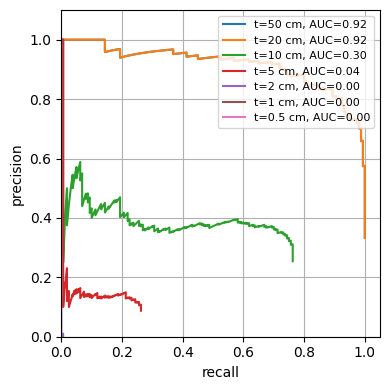

In [127]:
fig, axs = plt.subplots(1, 1, layout='tight', figsize=(4,4))

#axs.set_title('precision-recall curves for different thresholds',fontsize=10)

average_precision_lst = []
for thr in [50, 20, 10, 5, 2, 1, 0.5]: # in centimeters
    precisions, recalls, average_precision = mean_average_precision(predictions, true_trajectories, iou_thresh=thr)
    print(average_precision)
    average_precision_lst.append(average_precision)
    axs.plot(recalls, precisions, label=f't={thr} cm, AUC={average_precision:.2f}')
print('map', np.mean(average_precision_lst))

axs.grid(True)
axs.set_ylabel('precision',  fontsize=10)
axs.set_xlabel('recall',  fontsize=10)
axs.set_xlim(0, 1.05)
axs.set_ylim(0, 1.1)
axs.legend(loc='upper right', fontsize=8)
#axs.legend(loc='lower right', fontsize=8)

plt.savefig('precision-recall-standard-original.pdf')
#plt.savefig('precision-recall-standard-700.pdf')

/tmp/ipykernel_582379/318521647.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend(fontsize=10)


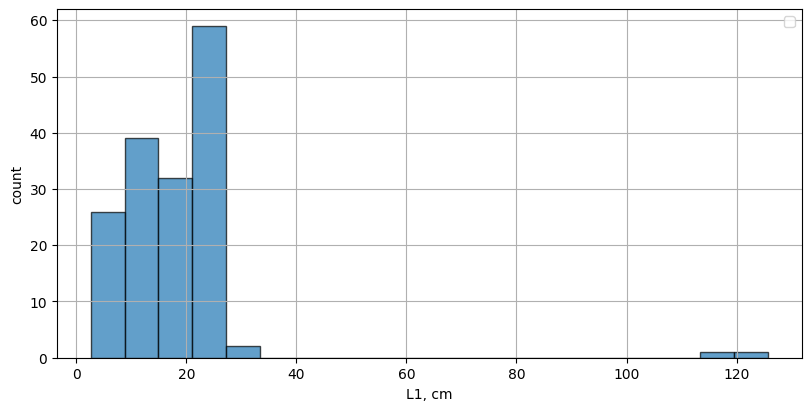

In [70]:
fig, axs = plt.subplots(1, 1, layout='constrained', figsize=(8,4))

ious = []
for i in range(len(true_trajectories)):
    image, sample = test_dataset[i] # image size 1280 x 720

    for j in range(i*3, (i+1)*3):
        iou = intersection_over_union(
            image,
            np.array(true_trajectories[i][2:]),  # x1, y1, x2, y2
            np.array(predictions[j][2:]),  # x1, y1, x2, y2
        )

    ious.append(iou)

#axs.set_title('L1, cm',fontsize=10)
axs.hist(ious, bins=20, alpha=0.7,  edgecolor='black')
#axs.plot(recalls, precisions, linestyle='-.', color='g', label='total')
axs.grid(True)
axs.set_xlabel('L1, cm',  fontsize=10)
axs.set_ylabel('count',  fontsize=10)
axs.legend(fontsize=10)